# 6. Hipótesis y KPIs orientados al inversor flipper

El proyecto se orienta al perfil de un inversor inmobiliario tipo **flipper** en Capital Federal. El objetivo de negocio es priorizar propiedades potencialmente subvaluadas, con margen de valorización mediante refacción y posterior reventa.

A partir del informe ejecutivo, los KPIs se organizan como una herramienta de decisión: precio de entrada, profundidad de mercado, stock mejorable, dotación de amenities, accesibilidad urbana, descuento frente a comparables e índice de oportunidad de flip.

El análisis debe interpretarse considerando que el dataset contiene precios de publicación y no precios efectivos de cierre. Tampoco contiene días de publicación, costos de obra, margen de negociación ni precio final de venta. Por lo tanto, los indicadores no miden ROI real, sino oportunidades teóricas para priorizar análisis inmobiliario más profundo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("../data/processed/Argenprop_limpio.csv", encoding="utf-8-sig")

# Compatibilidad con el dataset final: desde el notebook 7 las columnas del limpio
# quedaron prefijadas por origen. Este bloque recupera nombres conceptuales para
# mantener reproducibles los KPIs definidos originalmente en el informe ejecutivo.
def desprefijar_columnas(dataframe):
    prefixes = ("original_", "imputada_", "sintetica_", "enriquecida_")
    rename = {}
    for col in dataframe.columns:
        nuevo = col
        for pref in prefixes:
            if col.startswith(pref):
                nuevo = col[len(pref):]
                break
        rename[col] = nuevo
    dataframe = dataframe.rename(columns=rename)
    dataframe = dataframe.rename(columns={
        "id_registro": "ID_registro",
        "Banos": "Ba\u00f1os",
        "Balcon": "Balc\u00f3n",
        "Jardin": "Jard\u00edn"
    })
    return dataframe

if any(col.startswith(("original_", "imputada_", "sintetica_", "enriquecida_")) for col in df.columns):
    df = desprefijar_columnas(df)

df = df[(df["Precio"].notna()) & (df["Sup_Total_m2"].notna()) & (df["Sup_Total_m2"] > 0)].copy()
df["Precio_m2"] = df["Precio"] / df["Sup_Total_m2"]

amenities = [
    "Aire_acondicionado_individual", "Losa_radiante", "Gas_natural", "Agua_corriente",
    "Balc\u00f3n", "Terraza", "Jard\u00edn", "Patio", "Baulera", "Cochera",
    "Muebles_de_cocina", "Permite_Mascotas", "Ascensor", "Pileta", "Parrilla",
    "Gimnasio", "Sauna", "Laundry", "Vigilancia"
]
amenities = [col for col in amenities if col in df.columns]
df["Cantidad_amenities"] = df[amenities].sum(axis=1)
df["Rango_precio"] = pd.qcut(df["Precio"], q=4, labels=["Bajo", "Medio-bajo", "Medio-alto", "Alto"], duplicates="drop")

def inv_score(series):
    s = pd.to_numeric(series, errors="coerce")
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    clipped = s.clip(lo, hi)
    denom = hi - lo
    if pd.isna(denom) or denom == 0:
        return pd.Series(0, index=s.index)
    return (1 - (clipped - lo) / denom).clip(0, 1).fillna(0)

df["score_subte"] = inv_score(df["Dist_Subte_m"])
df["score_colectivos"] = (df["Paradas_colectivo_300m"] / df["Paradas_colectivo_300m"].quantile(0.99)).clip(0, 1).fillna(0)
df["score_avenida"] = inv_score(df["Dist_Avenida_m"])
df["score_hospital"] = inv_score(df["Dist_Hospital_m"])
df["score_colegio"] = inv_score(df["Dist_Colegio_m"])
df["score_supermercado"] = inv_score(df["Dist_Supermercado_m"])

df["Indice_accesibilidad"] = (
    0.25 * df["score_subte"] +
    0.20 * df["score_colectivos"] +
    0.20 * df["score_avenida"] +
    0.15 * df["score_hospital"] +
    0.10 * df["score_colegio"] +
    0.10 * df["score_supermercado"]
)

df["Estado_refaccion"] = df["Estado"].eq("A Refaccionar").astype(int)
df["Estado_mejorable"] = df["Estado"].isin(["A Refaccionar", "Regular", "Bueno"]).astype(int)

df["Dotacion_amenities"] = pd.qcut(
    df["Cantidad_amenities"],
    q=3,
    labels=["Baja dotacion", "Media dotacion", "Alta dotacion"],
    duplicates="drop"
)

print(f"Dataset utilizado: {df.shape[0]:,} propiedades y {df.shape[1]:,} variables")


Dataset utilizado: 7,245 propiedades y 68 variables


## Nivel descriptivo

Este nivel permite caracterizar el mercado desde la perspectiva del flipper: donde comprar, cuanto vale cada zona, donde hay mayor stock y que barrios concentran propiedades con posible necesidad de mejora.


### 1. Precio de entrada por zona

**KPI:** Precio promedio y mediano por m2 por barrio.

**Uso:** define el valor de referencia de cada barrio y permite detectar zonas caras, zonas accesibles y posibles mercados de entrada.

**Formula:** precio total publicado del barrio dividido por superficie total publicada del barrio. Se complementa con la mediana de precio por m2 para reducir el efecto de outliers.


In [2]:
precio_m2_barrio = (
    df.groupby("Barrio")
    .agg(
        propiedades=("Precio", "size"),
        precio_total=("Precio", "sum"),
        superficie_total=("Sup_Total_m2", "sum"),
        mediana_precio_m2=("Precio_m2", "median"),
        precio_mediano=("Precio", "median")
    )
    .assign(precio_prom_m2=lambda x: x["precio_total"] / x["superficie_total"])
    .sort_values("precio_prom_m2", ascending=False)
)

precio_m2_barrio[["propiedades", "precio_prom_m2", "mediana_precio_m2", "precio_mediano"]].head(10).round(1)


,propiedades,precio_prom_m2,mediana_precio_m2,precio_mediano
Barrio,,,,
Puerto Madero,74,"4,513.70","4,785.80","485,000.00"
Belgrano,311,"2,933.80","2,725.80","176,000.00"
Colegiales,292,"2,931.70","2,959.70","178,992.50"
Nuñez,165,"2,890.20","2,730.80","150,000.00"
Palermo,623,"2,821.80","2,684.20","165,000.00"
Saavedra,197,"2,677.20","2,753.80","145,000.00"
Coghlan,62,"2,588.50","2,530.40","126,500.00"
Villa Urquiza,246,"2,528.10","2,500.00","145,675.00"
Retiro,177,"2,492.60","2,238.80","145,000.00"


### 2. Profundidad de mercado y liquidez aproximada por barrio

**KPI:** Participacion de la oferta por barrio.

**Uso:** barrios con mas publicaciones ofrecen mas comparables, mejor lectura de precios y potencialmente mayor liquidez. Como no tenemos dias de publicacion ni operaciones cerradas, la cantidad de listings se usa como proxy de profundidad de mercado, no como liquidez real.

**Formula:** cantidad de propiedades del barrio sobre el total de propiedades publicadas.


In [3]:
oferta_barrio = df["Barrio"].value_counts().rename_axis("Barrio").reset_index(name="propiedades")
oferta_barrio["participacion_%"] = oferta_barrio["propiedades"] / len(df) * 100
oferta_barrio.head(10).round(2)


,Barrio,propiedades,participacion_%
0,Palermo,623,8.60
1,Balvanera,572,7.90
2,Recoleta,489,6.75
3,Flores,319,4.40
4,Caballito,317,4.38
5,Villa Crespo,314,4.33
6,Belgrano,311,4.29
7,Colegiales,292,4.03
8,Almagro,257,3.55
9,Villa Urquiza,246,3.40


### 3. Stock refaccionable o mejorable por barrio

**KPI 1:** Porcentaje de propiedades A Refaccionar por barrio.

**KPI 2:** Porcentaje de stock mejorable por barrio, considerando A Refaccionar, Regular y Bueno.

**Uso:** la categoria A Refaccionar es muy chica en el dataset. Por eso se agrega una definicion ampliada de stock mejorable para capturar inmuebles que podrian requerir mejoras y tener potencial de valorizacion.


In [4]:
stock_estado_barrio = (
    df.groupby("Barrio")
    .agg(
        propiedades=("Precio", "size"),
        pct_refaccion=("Estado_refaccion", "mean"),
        pct_mejorable=("Estado_mejorable", "mean"),
        precio_m2_mediana=("Precio_m2", "median")
    )
    .assign(
        pct_refaccion=lambda x: x["pct_refaccion"] * 100,
        pct_mejorable=lambda x: x["pct_mejorable"] * 100
    )
    .sort_values("pct_mejorable", ascending=False)
)

stock_estado_barrio[stock_estado_barrio["propiedades"] >= 30].head(12).round(1)


,propiedades,pct_refaccion,pct_mejorable,precio_m2_mediana
Barrio,,,,
La Boca,90,0.00,27.80,"1,395.10"
Villa Pueyrredon,111,0.00,20.70,"2,257.10"
San Cristobal,80,0.00,20.00,"1,666.70"
Villa Gral. Mitre,76,1.30,19.70,"2,012.40"
Recoleta,489,2.20,19.20,"2,346.90"
Almagro,257,1.20,17.50,"1,972.50"
Villa Real,46,4.30,17.40,"2,215.50"
San Nicolas,217,2.30,17.10,"1,856.40"
Barracas,178,1.10,16.30,"1,733.30"


### 4. Amenities y mejoras frecuentes por segmento de precio

**KPI 1:** Frecuencia relativa de amenities por rango de precio.

**KPI 2:** Cantidad promedio de amenities por rango de precio.

**Uso:** permite identificar que atributos diferencian propiedades de mayor valor y pueden orientar decisiones de refaccion o puesta en valor.


In [5]:
frecuencia_amenities = df.groupby("Rango_precio", observed=False)[amenities].mean().mul(100).round(1)
promedio_amenities = df.groupby("Rango_precio", observed=False)["Cantidad_amenities"].mean().round(2)

top_amenities_por_rango = []
for rango in frecuencia_amenities.index:
    top = frecuencia_amenities.loc[rango].sort_values(ascending=False).head(6)
    for amenity, porcentaje in top.items():
        top_amenities_por_rango.append({"Rango_precio": rango, "Amenity": amenity, "Frecuencia_%": porcentaje})

top_amenities_por_rango = pd.DataFrame(top_amenities_por_rango)
display(top_amenities_por_rango)
display(promedio_amenities.to_frame("Promedio amenities"))


,Rango_precio,Amenity,Frecuencia_%
0,Bajo,Agua_corriente,63.40
1,Bajo,Gas_natural,50.40
2,Bajo,Balcón,29.20
3,Bajo,Permite_Mascotas,24.20
4,Bajo,Ascensor,18.70
5,Bajo,Aire_acondicionado_individual,13.40
6,Medio-bajo,Agua_corriente,61.30
7,Medio-bajo,Balcón,50.20
8,Medio-bajo,Gas_natural,47.70
9,Medio-bajo,Permite_Mascotas,27.70


,Promedio amenities
Rango_precio,
Bajo,2.40
Medio-bajo,3.00
Medio-alto,3.13
Alto,3.98


### 5. Accesibilidad urbana por barrio

**KPI:** Indice de accesibilidad urbana.

**Uso:** prioriza propiedades con mejor entorno urbano, conectividad y acceso a servicios, factores que pueden facilitar la reventa.

**Formula:** 0.25 subte + 0.20 colectivos + 0.20 avenida + 0.15 hospital + 0.10 colegio + 0.10 supermercado.


In [6]:
accesibilidad_barrio = (
    df.groupby("Barrio")
    .agg(propiedades=("Precio", "size"), indice_accesibilidad=("Indice_accesibilidad", "mean"), precio_m2_mediana=("Precio_m2", "median"))
    .sort_values("indice_accesibilidad", ascending=False)
)

accesibilidad_barrio.head(10).round(3)


,propiedades,indice_accesibilidad,precio_m2_mediana
Barrio,,,
Balvanera,572,0.80,"1,679.13"
San Cristobal,80,0.79,"1,666.67"
Constitucion,144,0.78,"1,581.03"
Recoleta,489,0.77,"2,346.94"
Monserrat,179,0.77,"1,595.24"
Parque Patricios,95,0.74,"1,628.31"
Caballito,317,0.74,"2,227.27"
Almagro,257,0.73,"1,972.50"
San Telmo,48,0.73,"1,786.08"


## Nivel diagnostico

Este nivel busca detectar oportunidades: inmuebles baratos frente a comparables, barrios donde las mejoras parecen tener prima de precio y combinaciones de variables atractivas para una estrategia de compra, refaccion y reventa.


### 6. Descuento frente a comparables

**KPI:** Intensidad de subvaluacion frente a comparables.

**Uso:** identifica barrios donde existe mayor proporcion de propiedades publicadas por debajo de inmuebles comparables. Este KPI sirve para detectar mercados donde aparecen mas oportunidades relativas de entrada.

**Comparables utilizados:** mismo barrio, mismo tipo de unidad y misma cantidad de ambientes.

**Cambio metodologico:** no usamos la mediana de subvaluacion porque tiende a dar 0. Esto ocurre porque el precio comparable se calcula con la mediana del propio grupo; por construccion, la mitad de las propiedades queda por encima y la mitad por debajo del valor de referencia. Para verlo mejor se usan indicadores de intensidad:

- porcentaje de propiedades con cualquier descuento frente a comparables.
- porcentaje de propiedades con descuento fuerte, definido como subvaluacion mayor o igual a 15%.
- descuento promedio solo entre propiedades subvaluadas.
- percentil 75 de subvaluacion, para ver descuentos altos sin depender de casos extremos.


In [7]:
comparables = df.groupby(["Barrio", "Tipo_Unidad", "Ambientes"])["Precio_m2"].transform("median")
conteo_comparables = df.groupby(["Barrio", "Tipo_Unidad", "Ambientes"])["Precio_m2"].transform("size")

df["Precio_m2_comparable"] = comparables
df["N_comparables"] = conteo_comparables
df["Subvaluacion_%"] = ((df["Precio_m2_comparable"] - df["Precio_m2"]) / df["Precio_m2_comparable"] * 100).replace([np.inf, -np.inf], np.nan)
df["Subvaluacion_positiva_%"] = df["Subvaluacion_%"].clip(lower=0)

def promedio_subvaluadas(s):
    s = s[s > 0]
    return s.mean() if len(s) else 0

descuento_barrio = (
    df[df["N_comparables"] >= 5]
    .groupby("Barrio")
    .agg(
        propiedades=("Precio", "size"),
        pct_con_descuento=("Subvaluacion_%", lambda s: (s > 0).mean() * 100),
        pct_con_descuento_15=("Subvaluacion_%", lambda s: (s >= 15).mean() * 100),
        descuento_prom_subvaluadas=("Subvaluacion_%", promedio_subvaluadas),
        p75_subvaluacion=("Subvaluacion_positiva_%", lambda s: s.quantile(0.75)),
        precio_m2_mediana=("Precio_m2", "median")
    )
    .sort_values(["pct_con_descuento_15", "descuento_prom_subvaluadas"], ascending=False)
)

descuento_barrio[descuento_barrio["propiedades"] >= 30].head(12).round(1)


,propiedades,pct_con_descuento,pct_con_descuento_15,descuento_prom_subvaluadas,p75_subvaluacion,precio_m2_mediana
Barrio,,,,,,
Villa Lugano,54,48.10,37.00,31.70,31.50,"1,834.00"
Mataderos,65,47.70,35.40,25.90,23.40,"1,816.70"
La Boca,79,46.80,31.60,24.00,24.60,"1,393.90"
Colegiales,276,48.60,31.50,20.80,20.20,"2,986.10"
Chacarita,85,48.20,30.60,20.20,19.80,"2,437.50"
Liniers,54,50.00,29.60,18.50,18.20,"1,934.70"
Retiro,149,47.70,28.90,19.60,18.20,"2,230.80"
Barracas,167,47.30,28.10,21.90,19.60,"1,746.00"
Velez Sarsfield,32,46.90,28.10,20.50,22.40,"1,759.70"


### 7. Prima de precio asociada a mayor dotacion de amenities

**KPI:** Brecha de precio por m2 entre propiedades con alta y baja dotacion de amenities dentro de cada barrio.

**Uso:** aproxima si el mercado publica precios superiores para inmuebles mas equipados dentro de la misma zona. Puede orientar que barrios parecen premiar mas la mejora del producto.


In [8]:
brecha_amenities_barrio = df.groupby(["Barrio", "Dotacion_amenities"], observed=False)["Precio_m2"].mean().unstack()
brecha_amenities_barrio["brecha_alta_vs_baja"] = brecha_amenities_barrio["Alta dotacion"] - brecha_amenities_barrio["Baja dotacion"]
brecha_amenities_barrio = brecha_amenities_barrio.join(df.groupby("Barrio").size().rename("propiedades"))
brecha_amenities_barrio = brecha_amenities_barrio[brecha_amenities_barrio["propiedades"] >= 50]
brecha_amenities_barrio.sort_values("brecha_alta_vs_baja", ascending=False).head(12).round(1)


,Baja dotacion,Media dotacion,Alta dotacion,brecha_alta_vs_baja,propiedades
Barrio,,,,,
Monserrat,"1,666.10","1,628.60","2,511.20",845.10,179
Chacarita,"2,334.90","2,478.10","3,013.50",678.60,89
Villa Ortuzar,"2,262.70","2,373.20","2,827.30",564.60,51
Flores,"1,834.20","2,009.30","2,288.70",454.40,319
Villa Lugano,"1,750.60","1,684.10","2,195.00",444.30,77
Caballito,"2,197.30","2,288.10","2,590.80",393.50,317
Parque Chacabuco,"2,167.30","2,259.50","2,546.60",379.30,207
Balvanera,"1,669.00","1,819.30","2,045.60",376.60,572
Almagro,"1,962.00","2,066.00","2,324.20",362.20,257


#### Visualizacion ejecutiva: dotacion de amenities y precio publicado

El grafico resume la asociacion descriptiva entre dotacion de amenities y precio por m2. No mide el retorno de una refaccion ni demuestra causalidad.

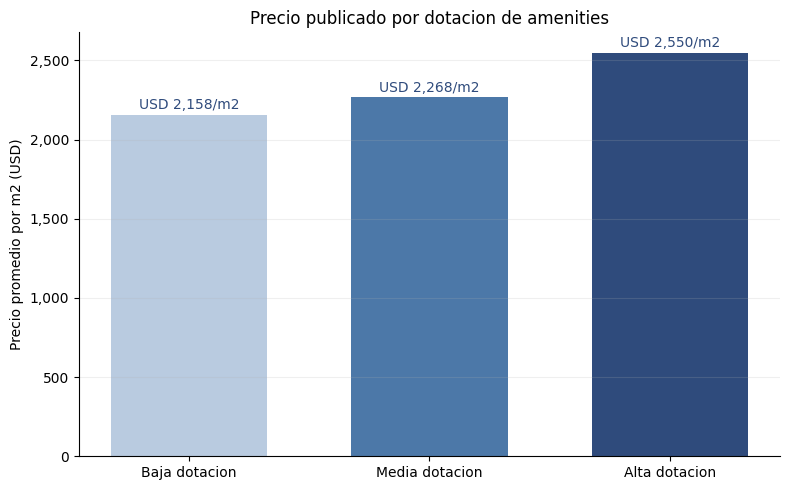

Brecha descriptiva alta vs. baja dotacion: USD 392.2/m2
Mayor brecha entre barrios con al menos 50 propiedades: USD 845.1/m2


In [9]:
precio_amenities = (
    df.groupby("Dotacion_amenities", observed=False)["Precio_m2"]
    .mean()
    .reindex(["Baja dotacion", "Media dotacion", "Alta dotacion"])
)
precio_amenities.rename("precio_m2_promedio").to_csv(
    "../data/processed/resumen_presentacion_amenities.csv",
    encoding="utf-8-sig"
)

fig, ax = plt.subplots(figsize=(8, 5))
colores = ["#B9CBE0", "#4C78A8", "#2F4B7C"]
barras = ax.bar(precio_amenities.index, precio_amenities.values, color=colores, width=0.65)
for barra, valor in zip(barras, precio_amenities.values):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 35, f"USD {valor:,.0f}/m2", ha="center", color="#2F4B7C")
ax.set_title("Precio publicado por dotacion de amenities")
ax.set_ylabel("Precio promedio por m2 (USD)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

brecha_global_amenities = precio_amenities["Alta dotacion"] - precio_amenities["Baja dotacion"]
print(f"Brecha descriptiva alta vs. baja dotacion: USD {brecha_global_amenities:,.1f}/m2")
print("Mayor brecha entre barrios con al menos 50 propiedades:",
      f"USD {brecha_amenities_barrio['brecha_alta_vs_baja'].max():,.1f}/m2")


### 8. Accesibilidad y precio por m2

**KPI:** Precio por m2 segun cuartil de accesibilidad urbana.

**Uso:** permite evaluar si las zonas mas accesibles tienen una prima de precio o si existen zonas accesibles con precios relativamente mas bajos.


In [10]:
df["Rango_accesibilidad"] = pd.qcut(df["Indice_accesibilidad"], q=4, labels=["Baja", "Media-baja", "Media-alta", "Alta"], duplicates="drop")

precio_accesibilidad = (
    df.groupby("Rango_accesibilidad", observed=False)
    .agg(
        propiedades=("Precio", "size"),
        precio_m2_prom=("Precio_m2", "mean"),
        precio_m2_mediana=("Precio_m2", "median"),
        precio_prom=("Precio", "mean")
    )
)

precio_accesibilidad.round(1)


,propiedades,precio_m2_prom,precio_m2_mediana,precio_prom
Rango_accesibilidad,,,,
Baja,1821,"2,369.00","2,222.20","173,865.00"
Media-baja,1808,"2,384.30","2,260.90","171,165.90"
Media-alta,1805,"2,323.40","2,187.00","160,011.10"
Alta,1811,"2,091.90","1,963.00","150,917.90"


#### Visualizacion ejecutiva: accesibilidad y precio publicado

Los cuartiles muestran un patron descriptivo. La comparacion no controla simultaneamente por barrio, superficie, estado u otras caracteristicas, por lo que no debe interpretarse como un efecto causal.

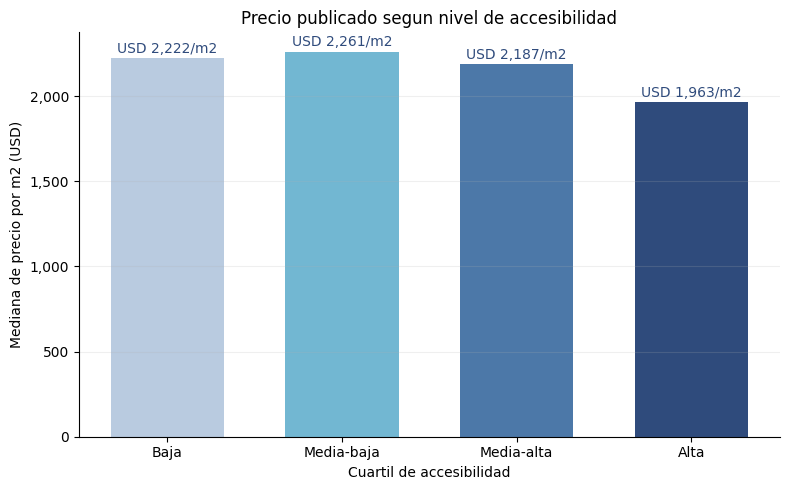

Diferencia descriptiva entre accesibilidad alta y baja: -11.7%


In [11]:
medianas_accesibilidad = precio_accesibilidad["precio_m2_mediana"]
precio_accesibilidad.to_csv(
    "../data/processed/resumen_presentacion_accesibilidad.csv",
    encoding="utf-8-sig"
)

fig, ax = plt.subplots(figsize=(8, 5))
colores = ["#B9CBE0", "#72B7D2", "#4C78A8", "#2F4B7C"]
barras = ax.bar(medianas_accesibilidad.index.astype(str), medianas_accesibilidad.values, color=colores, width=0.65)
for barra, valor in zip(barras, medianas_accesibilidad.values):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 30, f"USD {valor:,.0f}/m2", ha="center", color="#2F4B7C")
ax.set_title("Precio publicado segun nivel de accesibilidad")
ax.set_xlabel("Cuartil de accesibilidad")
ax.set_ylabel("Mediana de precio por m2 (USD)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

brecha_accesibilidad = 100 * (medianas_accesibilidad["Alta"] / medianas_accesibilidad["Baja"] - 1)
print(f"Diferencia descriptiva entre accesibilidad alta y baja: {brecha_accesibilidad:.1f}%")


### 9. Distancia al subte y umbral de valor

**KPI:** Precio promedio por m2 segun rango de distancia al subte y brecha entre rangos.

**Uso:** ayuda a entender si la cercania al transporte tiene una relacion clara con el precio o si debe analizarse junto con barrio y caracteristicas del inmueble.


In [12]:
bins = [0, 250, 500, 750, 1000, np.inf]
labels = ["0-250 m", "250-500 m", "500-750 m", "750-1000 m", "Mas de 1000 m"]
df["Rango_dist_subte"] = pd.cut(df["Dist_Subte_m"], bins=bins, labels=labels, include_lowest=True)

precio_transporte = (
    df.groupby("Rango_dist_subte", observed=False)
    .agg(
        propiedades=("Precio", "size"),
        precio_total=("Precio", "sum"),
        superficie_total=("Sup_Total_m2", "sum"),
        precio_m2_mediana=("Precio_m2", "median")
    )
    .assign(precio_prom_m2=lambda x: x["precio_total"] / x["superficie_total"])
)
precio_transporte["brecha_vs_rango_anterior"] = precio_transporte["precio_prom_m2"].diff()
precio_transporte[["propiedades", "precio_prom_m2", "precio_m2_mediana", "brecha_vs_rango_anterior"]].round(1)


,propiedades,precio_prom_m2,precio_m2_mediana,brecha_vs_rango_anterior
Rango_dist_subte,,,,
0-250 m,995,"2,114.80","1,973.70",NaN
250-500 m,2117,"2,222.80","2,124.30",108.00
500-750 m,1152,"2,453.90","2,230.60",231.10
750-1000 m,785,"2,581.50","2,404.60",127.70
Mas de 1000 m,2196,"2,219.90","2,142.90",-361.60


### 10. Indice de oportunidad de flip

**KPI principal:** Indice de oportunidad de flip.

**Uso:** sintetiza en un unico ranking las propiedades que combinan descuento frente a comparables, buena accesibilidad, potencial de zona, estado mejorable y profundidad de mercado.

**Formula propuesta:**

Indice = 0.40 descuento frente a comparables + 0.20 accesibilidad + 0.15 potencial de zona + 0.15 estado mejorable + 0.10 profundidad de mercado.

**Aclaracion:** no es ROI real. Es un scoring de priorizacion para investigar oportunidades, porque faltan costo de obra, precio de cierre, tiempo de venta y margen de negociacion.


In [13]:
potencial_zona = df.groupby("Barrio")["Precio_m2"].transform("median")
df["Potencial_zona"] = pd.qcut(potencial_zona.rank(method="first"), q=4, labels=False, duplicates="drop") / 3

subvaluacion_pos = df["Subvaluacion_%"].clip(lower=0)
df["score_subvaluacion"] = (subvaluacion_pos / subvaluacion_pos.quantile(0.99)).clip(0, 1).fillna(0)

densidad_barrio = df.groupby("Barrio")["Precio"].transform("size")
df["score_profundidad"] = (densidad_barrio / densidad_barrio.quantile(0.99)).clip(0, 1).fillna(0)

df["Indice_oportunidad_flip"] = 100 * (
    0.40 * df["score_subvaluacion"] +
    0.20 * df["Indice_accesibilidad"] +
    0.15 * df["Potencial_zona"].fillna(0) +
    0.15 * df["Estado_mejorable"] +
    0.10 * df["score_profundidad"]
)

top_oportunidades_flip = (
    df[(df["N_comparables"] >= 5) & (df["Subvaluacion_%"] > 0)]
    .sort_values("Indice_oportunidad_flip", ascending=False)
    [[
        "Barrio", "Tipo_Unidad", "Ambientes", "Estado", "Precio", "Sup_Total_m2", "Precio_m2",
        "Precio_m2_comparable", "Subvaluacion_%", "Indice_accesibilidad", "N_comparables", "Indice_oportunidad_flip"
    ]]
    .head(10)
)

top_oportunidades_flip.round(2)


,Barrio,Tipo_Unidad,Ambientes,Estado,Precio,Sup_Total_m2,Precio_m2,Precio_m2_comparable,Subvaluacion_%,Indice_accesibilidad,N_comparables,Indice_oportunidad_flip
6653,Palermo,Departamento,2,Bueno,"70,000.00",57.00,"1,228.07","2,725.00",54.93,0.81,103,96.12
6650,Palermo,Departamento,4,A Refaccionar,"125,000.00",80.00,"1,562.50","2,542.41",38.54,0.81,60,86.47
1008,Saavedra,Departamento,3,Bueno,"69,000.00",51.00,"1,352.94","2,812.50",51.90,0.62,21,85.53
51,Palermo,Semipiso,4,A Refaccionar,"270,000.00",150.00,"1,800.00","2,923.08",38.42,0.71,11,84.50
3077,Belgrano,Departamento,4,Bueno,"185,000.00",117.00,"1,581.20","2,802.82",43.59,0.76,31,84.47
1998,Palermo,Semipiso,3,Bueno,"139,000.00",79.00,"1,759.49","2,684.21",34.45,0.84,13,84.02
2902,Palermo,Semipiso,4,Bueno,"215,000.00",110.77,"1,940.92","2,923.08",33.60,0.87,11,83.94
259,Palermo,Departamento,4,Bueno,"150,000.00",90.00,"1,666.67","2,542.41",34.45,0.80,60,83.07
6273,Colegiales,No disponible,2,Bueno,"76,000.00",40.00,"1,900.00","3,593.85",47.13,0.53,53,82.43
945,Palermo,Departamento,2,Bueno,"74,000.00",43.00,"1,720.93","2,725.00",36.85,0.63,103,81.59
